# ROGII Wellbore Geology - LSTM Hyperparameter Optimization

Find the optimal BiLSTM configuration using **Keras Tuner Hyperband**.

**Features (6):** `MD, X, Y, Z, GR, TVT_input` (Masked for missing values)
**Backend**: JAX

**Author**: Samir Attrah

### 1. Environment & Imports
Setup JAX backend and import Keras Tuner along with modeling libraries.

In [1]:
# Cell 1: Environment & Imports
import os
os.environ["KERAS_BACKEND"] = "jax"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
jax.config.update("jax_enable_x64", True)

import keras
from keras import layers, callbacks, regularizers
import keras_tuner as kt
import jax.numpy as jnp
import numpy as np
import polars as pl
import glob, pickle, warnings, random
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"Keras: {keras.__version__}, Backend: {keras.backend.backend()}")


2026-06-01 06:44:42.300810: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780285482.345175   15526 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780285482.358961   15526 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras: 3.12.0, Backend: jax


### 2. Auto-detect Dataset Path
Identify the dataset location in the current environment.

In [2]:
# Cell 2: Data directory detection
def find_data_dir():
    candidates = [
        "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
        "/kaggle/input/rogii-wellbore-geology-prediction",
        "/home/samer/Documents/competitions/ROGII/dataset",
    ]
    for path in candidates:
        if os.path.isdir(path):
            if "train" in os.listdir(path): return path
    raise FileNotFoundError("Dataset not found.")

DATA_DIR = find_data_dir()


### 3. Data Preparation
Load well logs and generate sliding-window sequences for LSTM training.

In [3]:
# Cell 3: Data Preparation
FEATURE_COLS = ["MD", "X", "Y", "Z", "GR", "TVT_input"]
TARGET = "TVT"
WINDOW_SIZE = 2
MASK_VALUE = -10.0

def preprocess(df):
    # Only interpolate
    for col in FEATURE_COLS:
        if col in df.columns:
            df = df.with_columns(pl.col(col).interpolate())
    return df

def make_seqs(feats, tgts, ws):
    idx = range(0, len(feats) - ws + 1)
    X = np.empty((len(idx), ws, feats.shape[1]), dtype=np.float64)
    y = np.empty(len(idx), dtype=np.float64)
    for i, s in enumerate(idx):
        X[i] = feats[s:s+ws]
        y[i] = tgts[s+ws-1]
    return X, y

def prepare_data(data_dir, val_ratio=0.2, max_wells=None):
    pattern = os.path.join(data_dir, "train", "*__horizontal_well.csv")
    ids = sorted(os.path.basename(f).split("__")[0] for f in glob.glob(pattern))
    if max_wells: ids = ids[:max_wells]
    
    n_val = int(len(ids) * val_ratio)
    val_ids = set(np.random.permutation(ids)[:n_val])
    
    Xt_raw, yt_raw, Xv_raw, yv_raw = [], [], [], []
    for wid in ids:
        try:
            df = preprocess(pl.read_csv(os.path.join(data_dir, "train", f"{wid}__horizontal_well.csv")))
            # Fix missing target values instead of filtering
            df = df.with_columns(pl.col(TARGET).fill_null(strategy="mean"))
            if len(df) <= WINDOW_SIZE: continue
            
            f = df.select(FEATURE_COLS).to_numpy().astype(np.float64)
            t = df.select(TARGET).to_numpy().ravel().astype(np.float64)
            X, y = make_seqs(f, t, WINDOW_SIZE)
            
            (Xv_raw if wid in val_ids else Xt_raw).append(X)
            (yv_raw if wid in val_ids else yt_raw).append(y)
        except Exception as e:
            print(f"  Skip {wid}: {e}")

    Xt_all = np.concatenate(Xt_raw)
    yt_all = np.concatenate(yt_raw)
    Xv_all = np.concatenate(Xv_raw)
    yv_all = np.concatenate(yv_raw)

    # Calculate normalization stats using jnp.nanmean/nanstd (ignores NaNs)
    f_flat = Xt_all.reshape(-1, len(FEATURE_COLS))
    feat_mean = jnp.nanmean(jnp.array(f_flat, dtype=jnp.float64), axis=0)
    feat_std = jnp.nanstd(jnp.array(f_flat, dtype=jnp.float64), axis=0)
    
    # Handle edge cases (all NaNs or zero std)
    feat_mean = jnp.where(jnp.isnan(feat_mean), 0.0, feat_mean)
    feat_std = jnp.where(jnp.isnan(feat_std) | (feat_std == 0), 1.0, feat_std)
    
    target_mean = jnp.nanmean(jnp.array(yt_all, dtype=jnp.float64))
    target_std = jnp.nanstd(jnp.array(yt_all, dtype=jnp.float64))
    target_mean = jnp.where(jnp.isnan(target_mean), 0.0, target_mean)
    target_std = jnp.where(jnp.isnan(target_std) | (target_std == 0), 1.0, target_std)

    # Normalize (preserving NaNs)
    X_train_n = (jnp.array(Xt_all, dtype=jnp.float64) - feat_mean) / feat_std
    y_train_n = (jnp.array(yt_all, dtype=jnp.float64) - target_mean) / target_std
    X_val_n = (jnp.array(Xv_all, dtype=jnp.float64) - feat_mean) / feat_std
    y_val_n = (jnp.array(yv_all, dtype=jnp.float64) - target_mean) / target_std

    # Fill NaNs with MASK_VALUE in features, and 0.0 in labels (labels aren't masked)
    X_train_n = jnp.where(jnp.isnan(X_train_n), MASK_VALUE, X_train_n)
    X_val_n = jnp.where(jnp.isnan(X_val_n), MASK_VALUE, X_val_n)
    y_train_n = jnp.where(jnp.isnan(y_train_n), 0.0, y_train_n)
    y_val_n = jnp.where(jnp.isnan(y_val_n), 0.0, y_val_n)

    scaler = {
        "feature_cols": FEATURE_COLS,
        "feat_mean": np.array(feat_mean),
        "feat_std": np.array(feat_std),
        "target_mean": float(target_mean),
        "target_std": float(target_std),
        "mask_value": MASK_VALUE,
        "normalized": True
    }

    return np.array(X_train_n, dtype=np.float32), np.array(y_train_n, dtype=np.float32), \
           np.array(X_val_n, dtype=np.float32), np.array(y_val_n, dtype=np.float32), scaler

print("Loading data (Masked float64 SCALE)...")
X_train, y_train, X_val, y_val, scaler = prepare_data(DATA_DIR)
print(f"Data ready: Train={X_train.shape}, Val={X_val.shape}")

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
with open(os.path.join(OUT_DIR, "opt_scaler_params.pkl"), "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler parameters saved to {OUT_DIR}/opt_scaler_params.pkl")


Loading data (Masked float64 SCALE)...
Data ready: Train=(4054279, 2, 6), Val=(1037203, 2, 6)
Scaler parameters saved to ../outputs/opt_scaler_params.pkl


### 4. Define HyperModel & Tuner
Specify the search space for LSTM layers, units, regularization, and optimization parameters.

In [4]:
# Cell 4: Define HyperModel

class LSTMHyperModel(kt.HyperModel):
    def build(self, hp):
        model = keras.Sequential()
        model.add(layers.Input(shape=(WINDOW_SIZE, len(FEATURE_COLS))))
        
        # 1. Add Masking Layer
        model.add(layers.Masking(mask_value=MASK_VALUE))
        
        # Tune number of LSTM layers
        num_lstm_layers = hp.Int('num_lstm_layers', 2, 8, default=8)
        
        for i in range(num_lstm_layers):
            is_last = (i == num_lstm_layers - 1)
            units = hp.Int(f'lstm_units_{i+1}', 8, 64, step=8)
            model.add(layers.LSTM(
                units, 
                return_sequences=not is_last,
                kernel_regularizer=regularizers.L2(hp.Float('kr_rate', 1e-6, 1e-3, sampling='log')),
                dropout=hp.Float('dropout', 0.1, 0.5, step=0.1)
            ))
        
        model.add(layers.Dense(hp.Int('dense_units', 4, 32, step=4), activation='relu'))
        model.add(layers.Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))
        model.add(layers.Dense(1, activation='linear'))
        
        model.compile(
            optimizer=keras.optimizers.Adam(
                hp.Float('lr', 1e-4, 1e-2, sampling='log'),
                global_clipnorm=hp.Float('gcn', 0.5, 2.0, step=0.5)
            ),
            loss='mse',
            metrics=[keras.metrics.RootMeanSquaredError(name='rmse')]
        )
        return model

tuner = kt.Hyperband(
    LSTMHyperModel(),
    objective=kt.Objective("val_rmse", direction="min"),
    max_epochs=20,
    factor=3,
    directory="tuner_results",
    project_name="rogii_lstm_opt_masking",
    overwrite=True
)

print("Tuner initialized. Search space summary:")
tuner.search_space_summary()


Tuner initialized. Search space summary:
Search space summary
Default search space size: 14
num_lstm_layers (Int)
{'default': 8, 'conditions': [], 'min_value': 2, 'max_value': 8, 'step': 1, 'sampling': 'linear'}
lstm_units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
kr_rate (Float)
{'default': 1e-06, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
lstm_units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
lstm_units_3 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
lstm_units_4 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
lstm_units_5 (Int)
{'default': None, 'conditions': [], '

### 5. Run Optimization Search
Execute the Hyperband search process with EarlyStopping to find the best configuration.

In [5]:
# Cell 5: Run Optimization
stop_early = callbacks.EarlyStopping(monitor='val_rmse', patience=5)

print("Starting search...")
tuner.search(
    X_train, y_train, 
    epochs=20, 
    validation_data=(X_val, y_val), 
    batch_size=32,
    callbacks=[stop_early]
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Search complete. 
Best Learning Rate: {best_hps.get('lr')}
Best LSTM layers  : {best_hps.get('num_lstm_layers')}
Best Dense units  : {best_hps.get('dense_units')}
""")


Trial 30 Complete [00h 29m 15s]
val_rmse: 0.27485281229019165

Best val_rmse So Far: 0.20588217675685883
Total elapsed time: 17h 19m 42s

Search complete. 
Best Learning Rate: 0.0006068110204571213
Best LSTM layers  : 2
Best Dense units  : 24



### 6. Retrain Best Model
Build the model using optimal hyperparameters and perform full training before saving.

In [10]:
# Cell 6: Retrain Best Model
model = tuner.hypermodel.build(best_hps)
history = model.fit(
    X_train, y_train, 
    epochs=300, 
    validation_data=(X_val, y_val), 
    batch_size=8
)

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
model.save(f"{OUT_DIR}/optimized_lstm_model.keras")
print(f"Optimized model saved to {OUT_DIR}/optimized_lstm_model.keras")


Epoch 1/300
506785/506785 ━━━━━━━━━━━━━━━━━━━━ 825s 2ms/step - loss: 0.0702 - rmse: 0.2560 - val_loss: 0.0477 - val_rmse: 0.2081
Epoch 2/300
506785/506785 ━━━━━━━━━━━━━━━━━━━━ 793s 2ms/step - loss: 0.0556 - rmse: 0.2268 - val_loss: 0.0586 - val_rmse: 0.2337
Epoch 3/300
506785/506785 ━━━━━━━━━━━━━━━━━━━━ 825s 2ms/step - loss: 0.0527 - rmse: 0.2211 - val_loss: 0.0556 - val_rmse: 0.2278
Epoch 4/300
506785/506785 ━━━━━━━━━━━━━━━━━━━━ 738s 1ms/step - loss: 0.0511 - rmse: 0.2178 - val_loss: 0.0584 - val_rmse: 0.2342
Epoch 5/300
506785/506785 ━━━━━━━━━━━━━━━━━━━━ 740s 1ms/step - loss: 0.0501 - rmse: 0.2158 - val_loss: 0.0485 - val_rmse: 0.2123
Epoch 6/300
506785/506785 ━━━━━━━━━━━━━━━━━━━━ 740s 1ms/step - loss: 0.0493 - rmse: 0.2142 - val_loss: 0.0534 - val_rmse: 0.2237
Epoch 7/300
506785/506785 ━━━━━━━━━━━━━━━━━━━━ 790s 2ms/step - loss: 0.0487 - rmse: 0.2127 - val_loss: 0.0488 - val_rmse: 0.2131
Epoch 8/300
506785/506785 ━━━━━━━━━━━━━━━━━━━━ 741s 1ms/step - loss: 0.0483 - rmse: 0.2119 - val_

KeyboardInterrupt: 

In [11]:
# Cell 7: Evaluate (Normalized -> RAW SCALE)
best_model = keras.saving.load_model("../outputs/optimized_lstm_model.keras")

# Denormalize using scaler
target_mean = jnp.array(scaler["target_mean"], dtype=jnp.float64)
target_std = jnp.array(scaler["target_std"], dtype=jnp.float64)
y_val_raw = (jnp.array(y_val, dtype=jnp.float64) * target_std) + target_mean

# Predict on val set (normalized scale)
yp_n = best_model.predict(X_val, batch_size=512).ravel()

# Denormalize predictions
yp = (jnp.array(yp_n, dtype=jnp.float64) * target_std) + target_mean
yp = np.array(yp)

err = yp - y_val_raw
rmse = float(np.sqrt(np.mean(err ** 2)))
print(f"\nVal RMSE (RAW SCALE after denorm): {repr(rmse)}")


2026/2026 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

Val RMSE (RAW SCALE after denorm): 137.73504388717166


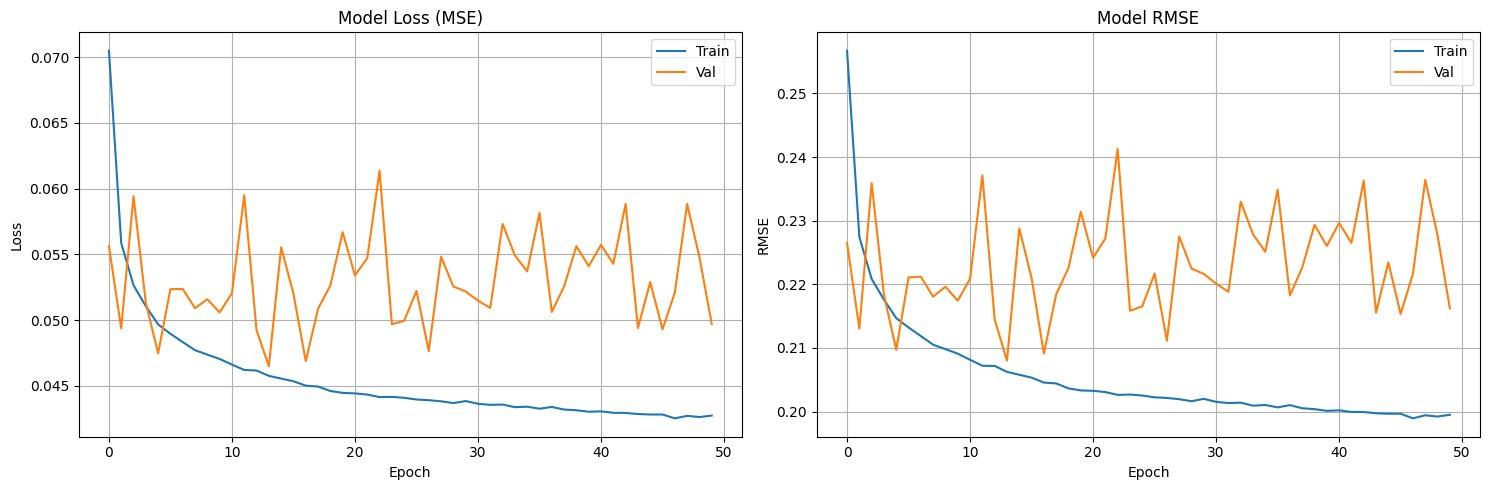

In [12]:
# Cell 8: Plot Training History
import matplotlib.pyplot as plt
import os

ANALYTICS_DIR = "../analytics"
os.makedirs(ANALYTICS_DIR, exist_ok=True)

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    ax1.plot(history.history['loss'], label='Train')
    ax1.plot(history.history['val_loss'], label='Val')
    ax1.set_title('Model Loss (MSE)')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True)
    
    # RMSE
    ax2.plot(history.history['rmse'], label='Train')
    ax2.plot(history.history['val_rmse'], label='Val')
    ax2.set_title('Model RMSE')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('RMSE')
    ax2.legend(); ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(ANALYTICS_DIR, "opt_training_history.png"))
    plt.show()

if 'history' in locals():
    plot_history(history)


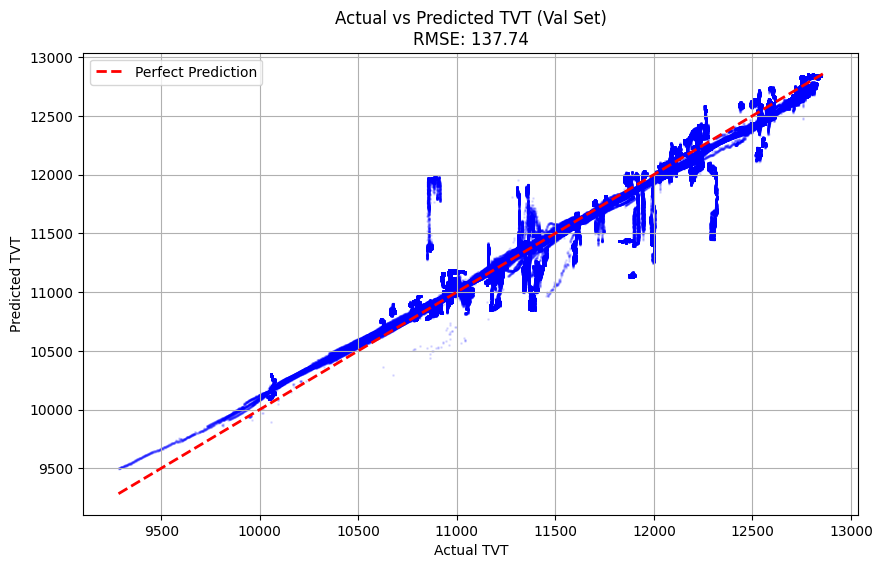

In [13]:
# Cell 9: Predicted vs Actual (Validation Set)
def plot_pred_vs_actual(y_true, y_pred):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.1, s=1, color='blue')
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    plt.title(f'Actual vs Predicted TVT (Val Set)\nRMSE: {rmse:.2f}')
    plt.xlabel('Actual TVT'); plt.ylabel('Predicted TVT')
    plt.legend(); plt.grid(True)
    
    plt.savefig(os.path.join(ANALYTICS_DIR, "opt_val_pred_vs_actual.png"))
    plt.show()

if 'y_val_raw' in locals() and 'yp' in locals():
    plot_pred_vs_actual(np.array(y_val_raw), yp)
